# PL

## PL Exciton/Trion Peak Mapping

**PL of `Mapping PL MoS2 Lines.txt`**

Expt setting:

- Data collection time: 2025/5/15
- Sampling site: centre, edge of the growth zone
- Exposure time: 0.3s
- Laser Power: 1%
- magnification: 100x
- Accumulation: 1
- Laser setting: central E = 1.83 $cm^{-1}$ ; laser = `532`nm ; grating: 1800 vis
- Step size: 0.5um

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\Mapping.py:171: FutureWarning: 
Using 'baseline_method="poly"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("poly", value)
or:
  baseline_method={'method': 'poly', 'param': value}
  self._baseline_method, self._baseline_kwargs = BaselineAPI.parse_spec(


Successful fits: 2115 / 2115


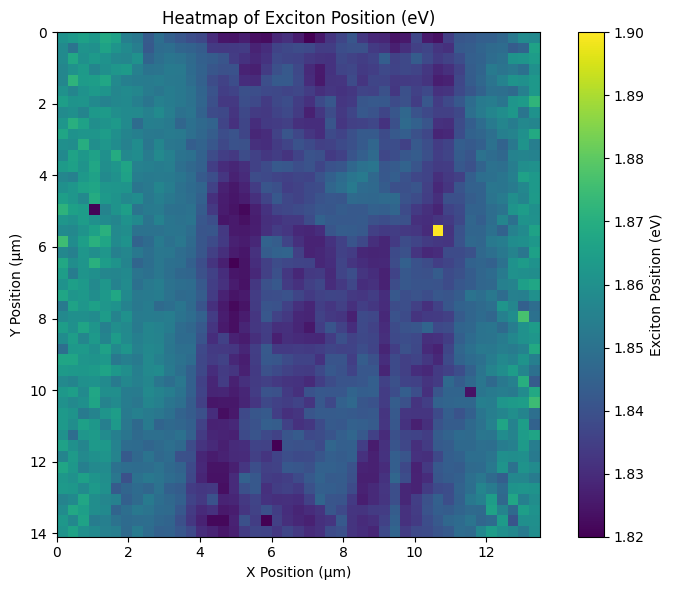

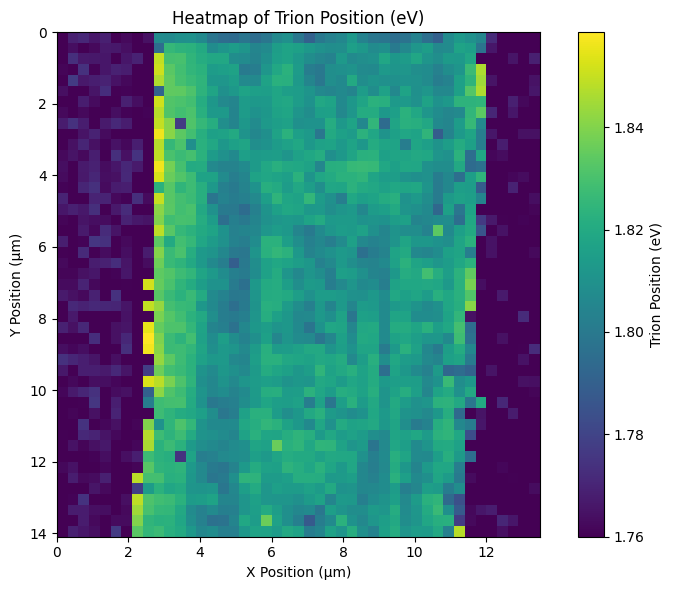

In [1]:
from ramanpl import Mapping

# Define custom peaks and data range
custom_peaks = {
    'Exciton': ([1.82, 0, 0], [1.9, 0.05, 0.1]),
    'Trion': ([1.76, 0, 0], [1.86, 0.05, 0.05])      # trion peak also fit if you think this is necesseary
}
x_range=(1.74, 1.88)      # by default, 1800vis grating gives 1013 data intensity measurement points

# Initialise the PLMapping class
pl_map = Mapping.PLMapping(
    filename='Mapping PL MoS2 Lines.txt',   # This is your file name. The code only works for .wdf files.
    custom_peaks=custom_peaks,
    step_size=0.3,              # Remember to correct to your step-size parameters 
    poly_degree=1,              # Degree of polynomial fitting for background
    background_remove=False,     # background_remove = True if you want to remove background 
    smoothing=False,             # smoothing=True if you want to smooth noisy signal
    baseline_method='poly',     # Options: 'poly', 'gaussian'
    data_range=x_range,       # If no data_range is given it will fit all over the spectrum
    normalize=False              # Normalize only affect how data is displyaed in heatmap, not fitting
)
# Fit the spectral data
pl_map.fit_spectra(warm_start=False, reset_on_fail=True)

# Plot exciton/trion position heatmap
pl_map.plot_heatmap(data_type='exciton_position')
pl_map.plot_heatmap(data_type='trion_position')




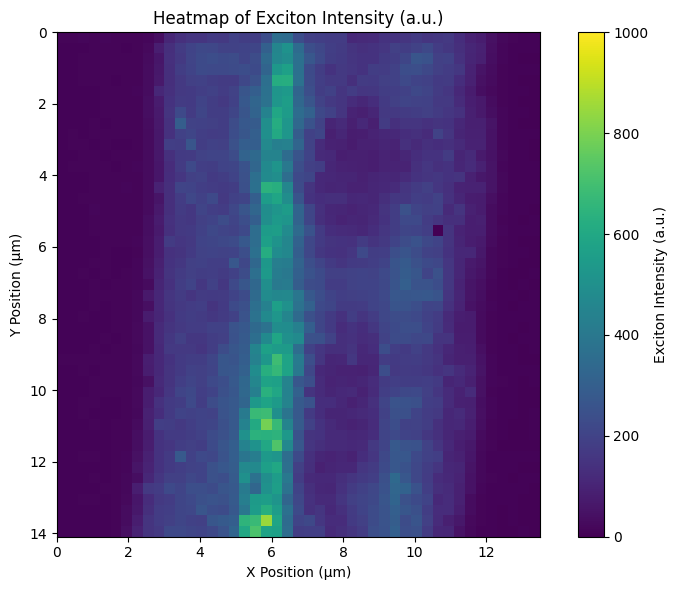

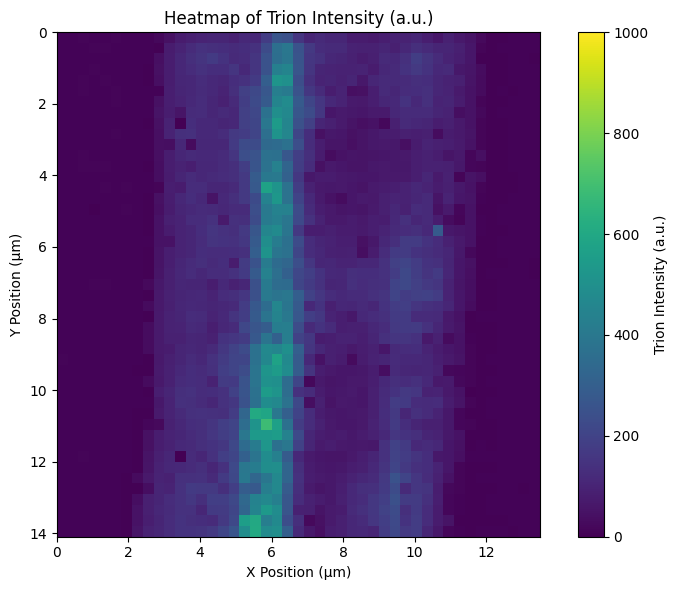

In [2]:
# Plot exciton/trion intensity heatmap
pl_map.plot_heatmap(data_type='exciton_intensity',
                    filter_range=[0,1000]
                    )
pl_map.plot_heatmap(data_type='trion_intensity',
                    filter_range=[0,1000]
                    )

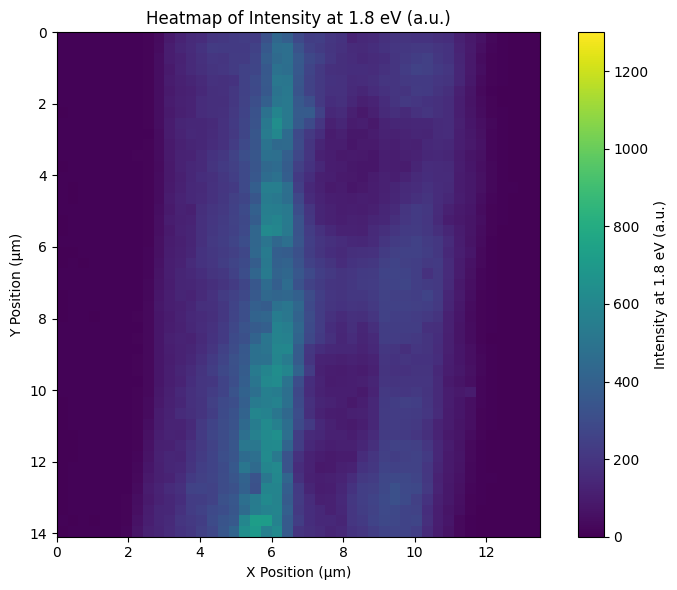

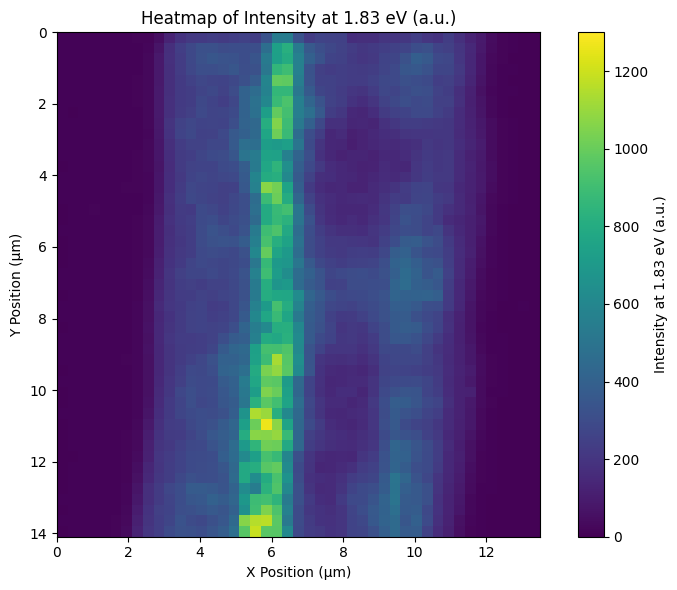

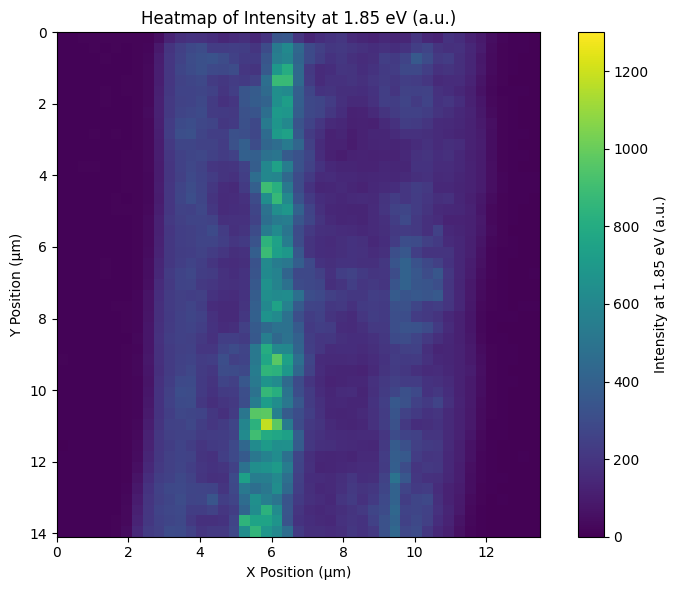

In [3]:
# Plot intensity at a specific eV (1.86 - 1.89eV)

for E in [1.8, 1.83, 1.85]:
    pl_map.plot_heatmap(data_type='specific_intensity', specific_xdata=E, 
                        filter_range=[0,1300]
                        )

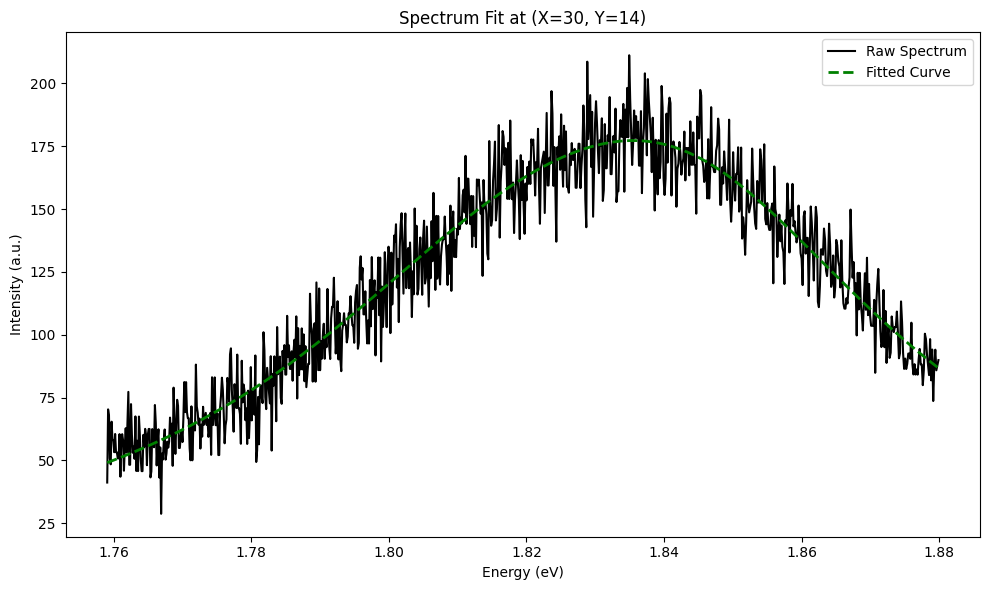

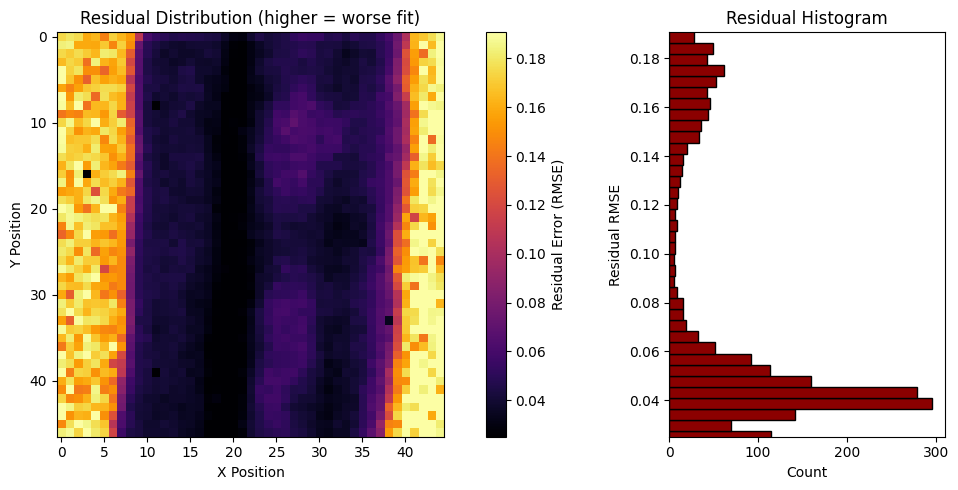

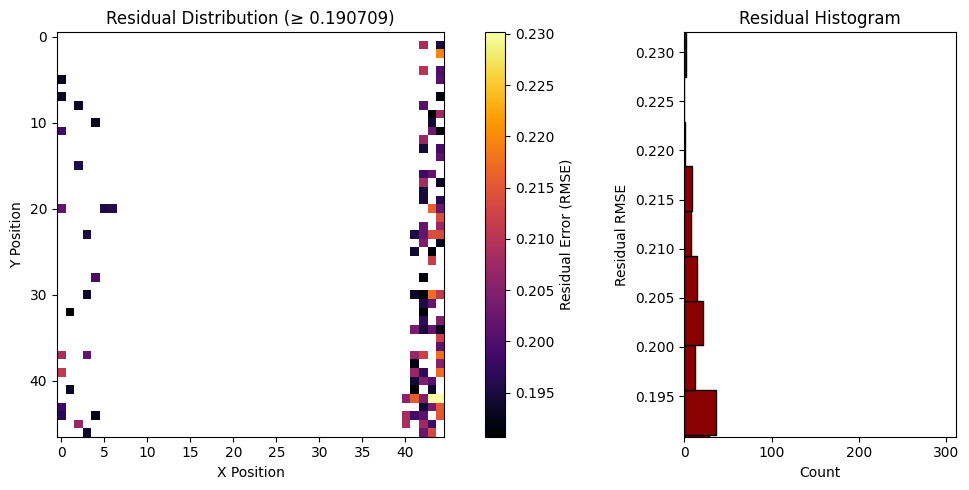

In [4]:
# Plot spectrum of a specific data point
pl_map.plot_spectrum_fit(x=30, y=14)  # x, y are the coordiate of a data point, remember to scale it with step-size

# Plot the fitting residual distribution to check quality of fitting
pl_map.plot_residual_distribution()

## Additional examples after version 0.2.2
import numpy as np
# Plot the fitting residual distribution to check quality of fitting with robust option and custom threshold
pl_map.plot_residual_distribution(
    robust=True,
    filter_threshold=np.nanpercentile(pl_map.residual_map, 95)
)


## Peak intensity integration

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\Mapping.py:770: FutureWarning: 
Using 'baseline_method="poly"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("poly", value)
or:
  baseline_method={'method': 'poly', 'param': value}
  self._baseline_method, self._baseline_kwargs = BaselineAPI.parse_spec(


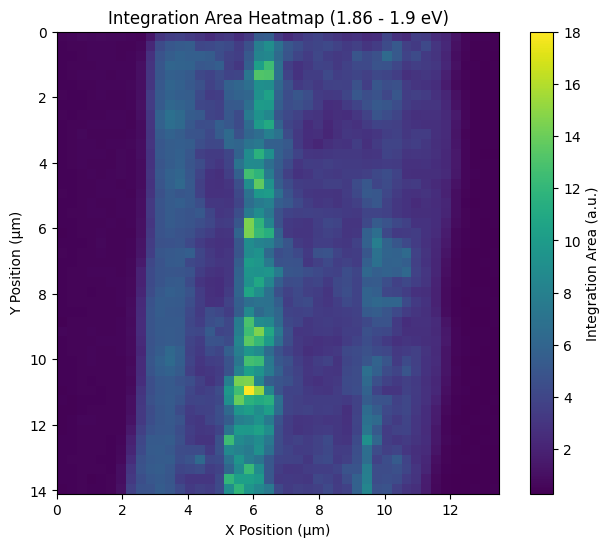

In [5]:
from ramanpl import Mapping

# Intialise PL_Integration object
pl_integration = Mapping.PL_Integration('Mapping PL MoS2 Lines.txt', 
                                integration_range=(1.86, 1.90),         # PL peak is 1.88eV, this example calculate the intensity near PL
                                step_size=0.3,                          # Step-size must follow correct setting
                                poly_degree=1, background_remove=False,  # Removing background is not necessary                          # Normalize only affect how data is displyaed in heatmap, not fitting
                                )

# Calculate
pl_integration.calculate_integration()

# Plot integration of PL heatmap
pl_integration.plot_integration_heatmap()
